In [96]:
# SARIMA Forecasting of Indian Inflation (CPI- Combined)

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [98]:
# Statsmodels imports
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [99]:
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [100]:
# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
pd.set_option('display.max_rows', 20)

In [101]:
print("="*70)
print("CPI INDIA FORECASTING - SARIMA MODEL")
print("Data: All India CPI Combined (General Index)")
print("Base: 2012 = 100")
print("="*70)

CPI INDIA FORECASTING - SARIMA MODEL
Data: All India CPI Combined (General Index)
Base: 2012 = 100


In [102]:

# STEP 1 : LOADING DATA FROM CSV


In [103]:
file_path = '/Users/abhishek/Desktop/CPI_Combined.csv'
df_raw = pd.read_csv(file_path)

In [105]:
print(f"\nRaw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")



Raw data shape: (4347, 6)
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


In [107]:
df_raw = pd.read_csv(file_path, skiprows=7, header=None)
df_raw.head()

,0,1,2,3,4,5
0,NaN,NOV-2025,A) General Index,Final,197.9,0.71
1,NaN,NOV-2025,A.1) Food and beverages,Final,202.6,-2.78
2,NaN,NOV-2025,A.1.1) Cereals and products,Final,197.5,0.10
3,NaN,NOV-2025,A.1.2) Meat and fish,Final,229.7,2.54
4,NaN,NOV-2025,A.1.3) Egg,Final,209.2,3.87


In [108]:
df_raw.columns = ['Empty', 'Month', 'Commodity_Description', 'Provisional_Final', 'Combined_Index', 'Inflation']


In [109]:
print("Columns now:")
print(df_raw.columns.tolist())
print("\n" + "="*50)

Columns now:
['Empty', 'Month', 'Commodity_Description', 'Provisional_Final', 'Combined_Index', 'Inflation']



In [110]:
print("First 10 rows:")
print(df_raw.head(10))

First 10 rows:
   Empty     Month        Commodity_Description Provisional_Final  \
0    NaN  NOV-2025             A) General Index             Final   
1    NaN  NOV-2025      A.1) Food and beverages             Final   
2    NaN  NOV-2025  A.1.1) Cereals and products             Final   
3    NaN  NOV-2025         A.1.2) Meat and fish             Final   
4    NaN  NOV-2025                   A.1.3) Egg             Final   
5    NaN  NOV-2025     A.1.4) Milk and products             Final   
6    NaN  NOV-2025         A.1.5) Oils and fats             Final   
7    NaN  NOV-2025                A.1.6) Fruits             Final   
8    NaN  NOV-2025            A.1.7) Vegetables             Final   
9    NaN  NOV-2025   A.1.8) Pulses and products             Final   

   Combined_Index  Inflation  
0           197.9       0.71  
1           202.6      -2.78  
2           197.5       0.10  
3           229.7       2.54  
4           209.2       3.87  
5           192.0       2.45  
6       

In [111]:
#Filtering for General Index only
cpi_data = df_raw[df_raw['Commodity_Description'] == 'A) General Index'].copy()
print(f"\nGeneral Index rows found: {len(cpi_data)}")
print(cpi_data[['Month', 'Combined_Index']].head(10))


General Index rows found: 155
        Month  Combined_Index
0    NOV-2025           197.9
28   OCT-2025           197.3
56   SEP-2025           197.0
84   AUG-2025           197.0
112  JUL-2025           196.1
140  JUN-2025           194.2
168  MAY-2025           193.0
196  APR-2025           192.6
224  MAR-2025           192.0
252  FEB-2025           192.5


In [112]:
# Rename columns for clarity
cpi_data = cpi_data.rename(columns={'Month': 'Date', 'Combined_Index': 'CPI_Index'})

In [113]:
# Convert Date to datetime (format: MON-YYYY)
def parse_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%b-%Y')
    except:
        return pd.NaT

cpi_data['Date'] = cpi_data['Date'].apply(parse_date)

In [114]:
# Drop any rows with invalid dates
cpi_data = cpi_data.dropna(subset=['Date'])

In [115]:
# Sort by date
cpi_data = cpi_data.sort_values('Date')

In [116]:
cpi_data.head()

,Empty,Date,Commodity_Description,Provisional_Final,CPI_Index,Inflation
4312,NaN,2013-01-01,A) General Index,Final,104.6,NaN
4284,NaN,2013-02-01,A) General Index,Final,105.3,NaN
4256,NaN,2013-03-01,A) General Index,Final,105.5,NaN
4228,NaN,2013-04-01,A) General Index,Final,106.1,NaN
4200,NaN,2013-05-01,A) General Index,Final,106.9,NaN


In [117]:
# Set as index
cpi_data.set_index('Date', inplace=True)

In [118]:
# Ensure monthly frequency
cpi_data = cpi_data.asfreq('MS')

In [119]:
# Check for missing values
print(f"\nMissing values: {cpi_data['CPI_Index'].isnull().sum()}")


Missing values: 0


In [120]:
# Fill any missing values with interpolation
cpi_data['CPI_Index'] = cpi_data['CPI_Index'].interpolate(method='linear')

print(f"\nFinal data shape: {cpi_data.shape}")
print(f"Date range: {cpi_data.index.min()} to {cpi_data.index.max()}")
print(f"\nLast 12 observations:")
print(cpi_data.tail(12))


Final data shape: (155, 5)
Date range: 2013-01-01 00:00:00 to 2025-11-01 00:00:00

Last 12 observations:
            Empty Commodity_Description Provisional_Final  CPI_Index  \
Date                                                                   
2024-12-01    NaN      A) General Index             Final      195.4   
2025-01-01    NaN      A) General Index             Final      193.4   
2025-02-01    NaN      A) General Index             Final      192.5   
2025-03-01    NaN      A) General Index             Final      192.0   
2025-04-01    NaN      A) General Index             Final      192.6   
2025-05-01    NaN      A) General Index             Final      193.0   
2025-06-01    NaN      A) General Index             Final      194.2   
2025-07-01    NaN      A) General Index             Final      196.1   
2025-08-01    NaN      A) General Index             Final      197.0   
2025-09-01    NaN      A) General Index             Final      197.0   
2025-10-01    NaN      A) Gene

In [121]:

# STEP 2  EXPLORATORY DATA ANALYSIS 


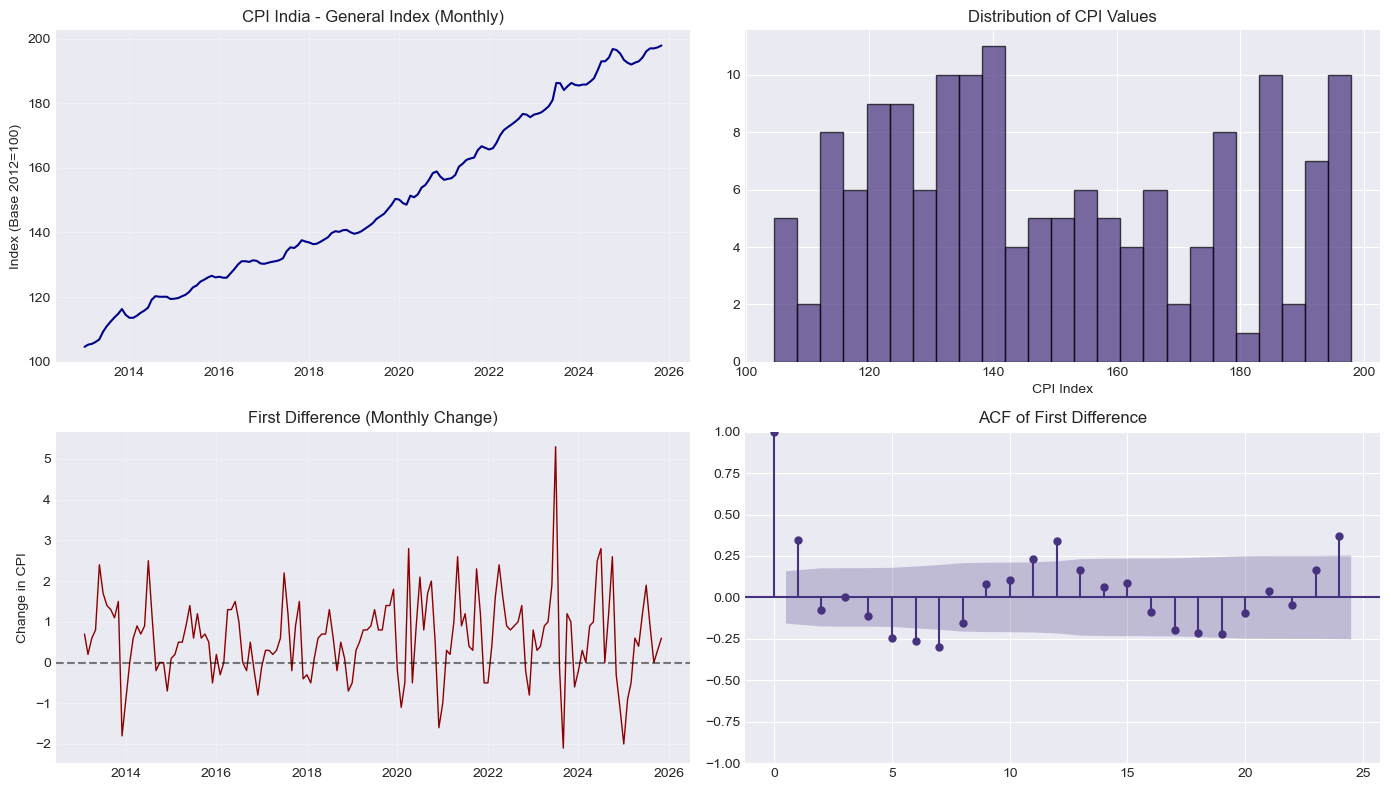

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time series plot
axes[0,0].plot(cpi_data.index, cpi_data['CPI_Index'], linewidth=1.5, color='darkblue')
axes[0,0].set_title('CPI India - General Index (Monthly)', fontsize=12)
axes[0,0].set_ylabel('Index (Base 2012=100)')
axes[0,0].grid(True, alpha=0.3)

# Histogram
axes[0,1].hist(cpi_data['CPI_Index'], bins=25, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribution of CPI Values', fontsize=12)
axes[0,1].set_xlabel('CPI Index')

# First difference
first_diff = cpi_data['CPI_Index'].diff().dropna()
axes[1,0].plot(first_diff.index, first_diff, linewidth=1, color='darkred')
axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,0].set_title('First Difference (Monthly Change)', fontsize=12)
axes[1,0].set_ylabel('Change in CPI')
axes[1,0].grid(True, alpha=0.3)

# ACF of first difference
plot_acf(first_diff, ax=axes[1,1], lags=24, alpha=0.05)
axes[1,1].set_title('ACF of First Difference', fontsize=12)

plt.tight_layout()
plt.savefig('cpi_eda.png', dpi=300, bbox_inches='tight')
plt.show()



In [123]:

# STEP 3 : STATIONARITY TEST (ADF)


In [124]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\nADF Test on {title}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f'  ✓ Stationary (reject H0)')
    else:
        print(f'  ✗ Non-stationary (fail to reject H0)')
    return result[1] <= 0.05

print("\n" + "="*70)
print("STATIONARITY TEST")
print("="*70)

adf_test(cpi_data['CPI_Index'], 'Original CPI')
adf_test(first_diff, 'First Difference of CPI')


STATIONARITY TEST

ADF Test on Original CPI:
  ADF Statistic: 1.0472
  p-value: 0.9947
  Critical Values:
    1%: -3.4756
    5%: -2.8814
    10%: -2.5774
  ✗ Non-stationary (fail to reject H0)

ADF Test on First Difference of CPI:
  ADF Statistic: -8.0040
  p-value: 0.0000
  Critical Values:
    1%: -3.4756
    5%: -2.8814
    10%: -2.5774
  ✓ Stationary (reject H0)


np.True_

In [125]:

# STEP 4 : SEASONAL DECOMPOSITION 


In [126]:
# Ensure frequency is set
cpi_data = cpi_data.asfreq('MS')

decomposition = seasonal_decompose(cpi_data['CPI_Index'], model='additive', period=12)


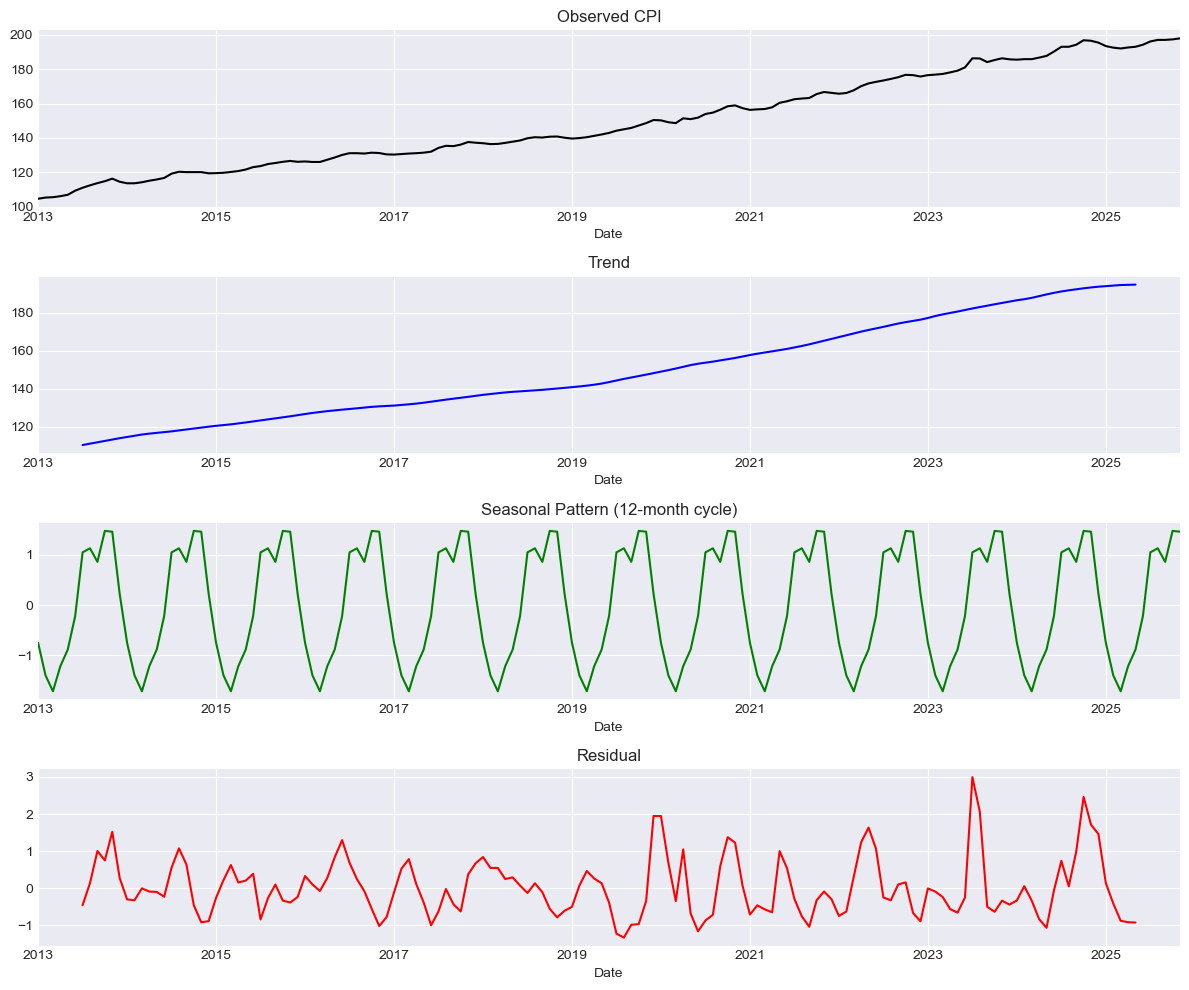

In [127]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], legend=False, color='black')
axes[0].set_title('Observed CPI')
decomposition.trend.plot(ax=axes[1], legend=False, color='blue')
axes[1].set_title('Trend')
decomposition.seasonal.plot(ax=axes[2], legend=False, color='green')
axes[2].set_title('Seasonal Pattern (12-month cycle)')
decomposition.resid.plot(ax=axes[3], legend=False, color='red')
axes[3].set_title('Residual')

plt.tight_layout()
plt.savefig('cpi_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()


In [128]:
# STEP 5 : TRAIN TEST SPLIT 

In [129]:
# Using last 12 months for testing
train_size = len(cpi_data) - 12
train = cpi_data.iloc[:train_size]['CPI_Index']
test = cpi_data.iloc[train_size:]['CPI_Index']



In [130]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training period: {train.index[0]} to {train.index[-1]}")
print(f"Training observations: {len(train)}")
print(f"Testing period: {test.index[0]} to {test.index[-1]}")
print(f"Testing observations: {len(test)}")



TRAIN-TEST SPLIT
Training period: 2013-01-01 00:00:00 to 2024-11-01 00:00:00
Training observations: 143
Testing period: 2024-12-01 00:00:00 to 2025-11-01 00:00:00
Testing observations: 12


In [131]:

# STEP 6 : FITTING SARIMA MODEL 


In [132]:
# For monthly CPI data with strong seasonality:
# p,d,q = 1,1,1 (common for economic data)
# P,D,Q,m = 1,1,1,12 (seasonal with 12-month cycle)
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

print("\n" + "="*70)
print("FITTING SARIMA MODEL")
print(f"Order: {order}")
print(f"Seasonal Order: {seasonal_order}")
print("="*70)


FITTING SARIMA MODEL
Order: (1, 1, 1)
Seasonal Order: (1, 1, 1, 12)


In [133]:
model = SARIMAX(train, 
                order=order, 
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          CPI_Index   No. Observations:                  143
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -140.439
Date:                            Fri, 24 Apr 2026   AIC                            290.879
Time:                                    10:53:31   BIC                            304.647
Sample:                                01-01-2013   HQIC                           296.468
                                     - 11-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3155      0.213     -1.484      0.138      -0.732       0.101
ma.L1          0.6332      0.182   

In [134]:

# STEP 7 : FORECASTING AND EVALUATION


In [135]:
forecast = results.forecast(steps=len(test))
forecast.index = test.index

# Calculate errors
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("\n" + "="*70)
print("FORECAST EVALUATION")
print("="*70)
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


FORECAST EVALUATION
MAE:  5.07
RMSE: 5.49
MAPE: 2.60%


In [136]:

# STEP 8: VISUALIZING RESULTS 


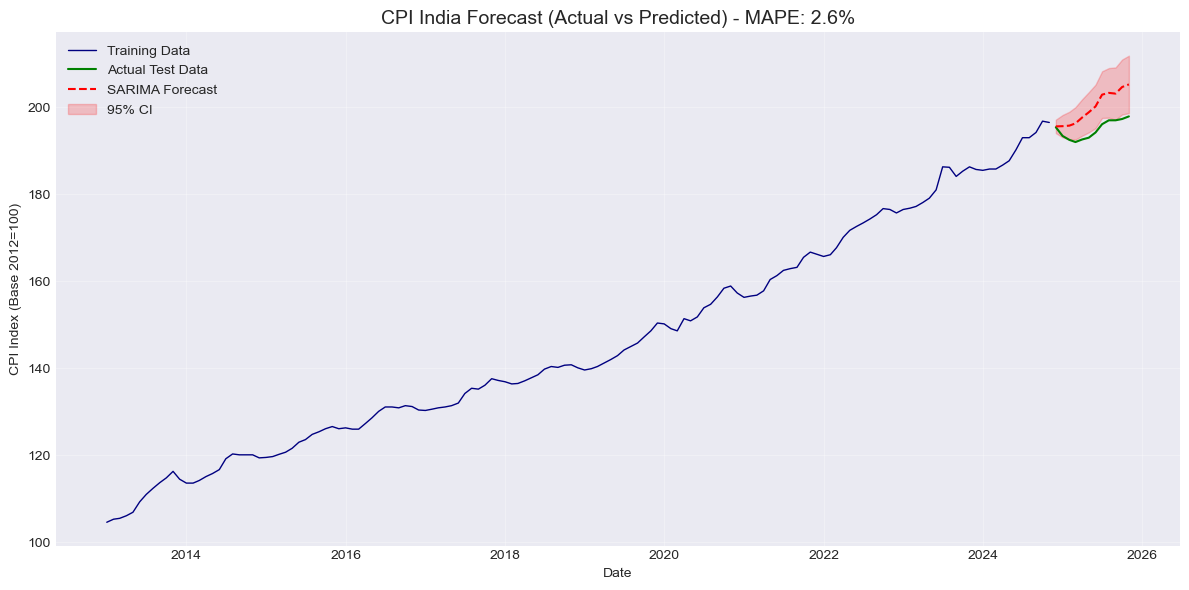

In [137]:
fig, ax = plt.subplots(figsize=(12, 6))

# Training data
ax.plot(train.index, train, label='Training Data', color='navy', linewidth=1)

# Actual test data
ax.plot(test.index, test, label='Actual Test Data', color='green', linewidth=1.5)

# Forecast
ax.plot(forecast.index, forecast, label='SARIMA Forecast', 
        color='red', linewidth=1.5, linestyle='--')

# Confidence intervals
pred_int = results.get_forecast(steps=len(test)).conf_int()
ax.fill_between(forecast.index, 
                pred_int.iloc[:, 0], 
                pred_int.iloc[:, 1], 
                color='red', alpha=0.2, label='95% CI')

ax.set_title(f'CPI India Forecast (Actual vs Predicted) - MAPE: {mape:.1f}%', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index (Base 2012=100)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cpi_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

In [138]:

# STEP 9: FUTURE FORECAST (NEXT 12 MONTHS)


In [139]:
future_forecast = results.forecast(steps=12)
future_dates = pd.date_range(start=test.index[-1] + pd.DateOffset(months=1), 
                              periods=12, freq='MS')

print("\n" + "="*70)
print("NEXT 12 MONTHS FORECAST")
print("="*70)
print(f"{'Month':<12} {'Forecasted CPI':<20}")
print("-"*35)
for i, (date, value) in enumerate(zip(future_dates, future_forecast)):
    print(f"{date.strftime('%b %Y'):<12} {value:.2f}")




NEXT 12 MONTHS FORECAST
Month        Forecasted CPI      
-----------------------------------
Dec 2025     195.60
Jan 2026     195.65
Feb 2026     195.77
Mar 2026     196.29
Apr 2026     197.66
May 2026     198.83
Jun 2026     200.19
Jul 2026     202.90
Aug 2026     203.30
Sep 2026     203.14
Oct 2026     204.65
Nov 2026     205.25


In [140]:

# STEP 10 : DIAGONISTIC CHECKS 


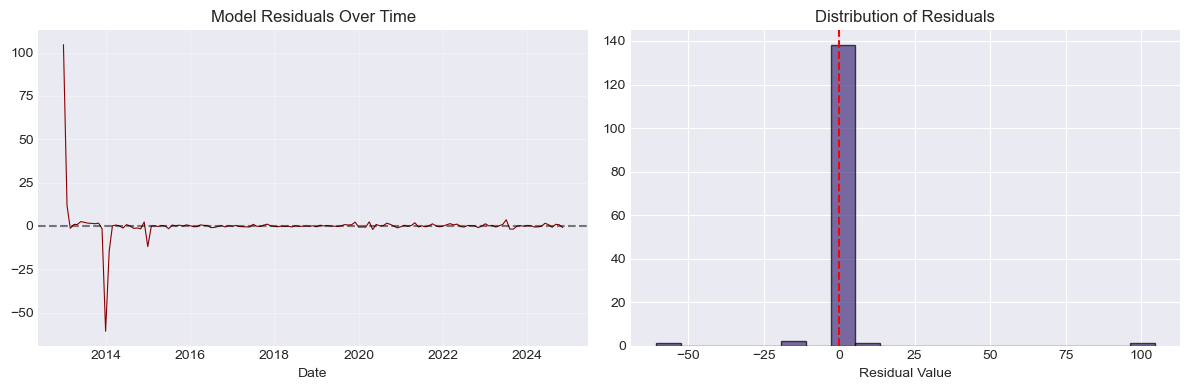

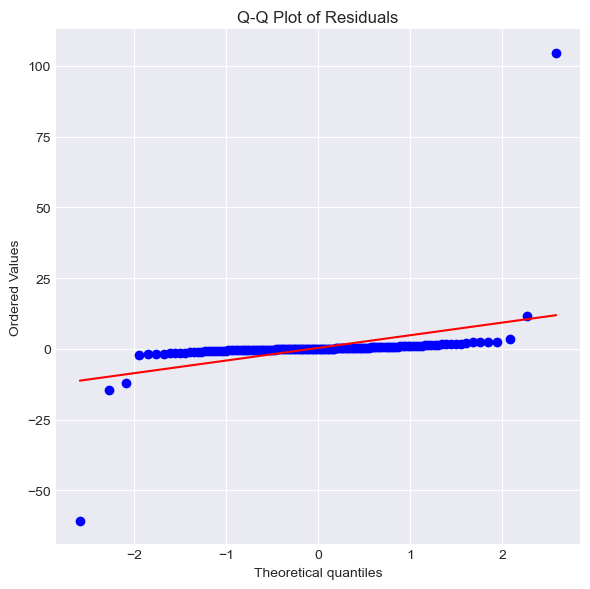


ANALYSIS COMPLETE!
Saved images:
  - cpi_eda.png
  - cpi_decomposition.png
  - cpi_forecast.png
  - cpi_residuals.png
  - cpi_qqplot.png


In [141]:
residuals = results.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals over time
axes[0].plot(residuals.index, residuals, color='darkred', linewidth=0.8)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Model Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('cpi_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# Q-Q plot for normality check (optional)
from scipy import stats
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig('cpi_qqplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("Saved images:")
print("  - cpi_eda.png")
print("  - cpi_decomposition.png")
print("  - cpi_forecast.png")
print("  - cpi_residuals.png")
print("  - cpi_qqplot.png")
print("="*70)

In [142]:

# COMPARING WITH YOY INLFATION RATE 


In [143]:
cpi_data['YoY_Inflation'] = cpi_data['CPI_Index'].pct_change(12) * 100

print("\n" + "="*70)
print("RECENT INFLATION RATES (YoY %)")
print("="*70)
print(cpi_data[['CPI_Index', 'YoY_Inflation']].tail(12).round(2))


RECENT INFLATION RATES (YoY %)
            CPI_Index  YoY_Inflation
Date                                
2024-12-01      195.4           5.22
2025-01-01      193.4           4.26
2025-02-01      192.5           3.61
2025-03-01      192.0           3.34
2025-04-01      192.6           3.16
2025-05-01      193.0           2.82
2025-06-01      194.2           2.10
2025-07-01      196.1           1.61
2025-08-01      197.0           2.07
2025-09-01      197.0           1.44
2025-10-01      197.3           0.25
2025-11-01      197.9           0.71
